In [ ]:
import math
import sys

import numpy as np
import matplotlib.pyplot as plt


#### Predicting the chaotic logistic map with an ESN

Let's make an ESN to predict the logistic map, which is a representative one-dimensional discrete dynamical system.
The logistic map is represented by the following equation:

$$
\begin{align*}
x[k+1] = a x[k] (1 - x[k])
.\end{align*}
$$

- $k \in \mathbb{Z} $: Discrete time
- $x[k] \in \mathbb{R} $: System state
- $a \in \mathbb{R} $: Parameter (constant)

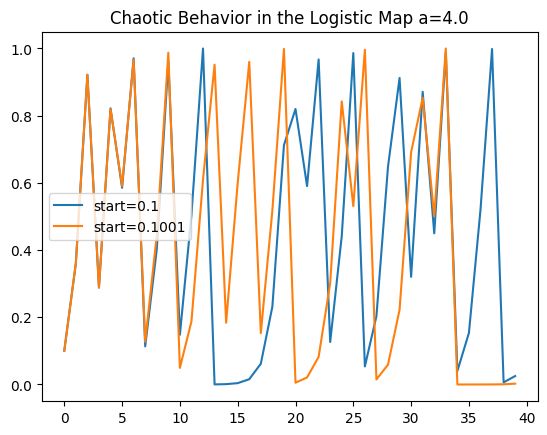

In [ ]:
def logistic_func(z, a=4.0):
    z_dot = a * z * (1 - z)
    return z_dot

def generate_logistic_series(start=0.1,a=4.0,length=100):
    series = [start]
    for _ in range(length - 1):
        next_value = logistic_func(series[-1], a)
        series.append(next_value)
    return series

a=4.0
x_series = generate_logistic_series(0.1,a,40)
y_series = generate_logistic_series(0.1001,a,40)


plt.plot(x_series, label="start=0.1")
plt.plot(y_series, label="start=0.1001")
plt.title("Chaotic Behavior in the Logistic Map a="+ str(a))
plt.legend()
plt.show()



The logistic map has the following attractors:
- Fixed point, for the range $ a < 3$
- Periodic orbits, for the range $3 \leq a \leq 3.569...$ (with period-doubling bifurcations in between).
- Chaos, for the range $3.569 < a$ (with some regions having 3-period orbits, etc.).

We will train an ESN to predict the chaotic case. The above graph shows how initally very similar inputs can lead to very different outputs. Due to rounding error, the series starting at 0.1001 eventually collapses to 0.

The internal state and output are defined as follows:

$$
\begin{align*}
x[k+1] &= (1-a)~x[k] + a~{f}(W^\mathrm{rec}x[k] + W^\mathrm{in} u[k+1]) \\
\hat{y}[k] &= {W^\mathrm{out}}^\top [1 ; x[k]] \\
&= {W^\mathrm{out}}^\top {[1 \quad x_1[k] \quad \cdots \quad x_{N}[k]]}^\top \\
&= W^\mathrm{out}_0 + \sum_{i=1}^{N} W^\mathrm{out}_i x_{i}[k]
,\end{align*}
$$

with activation function e.g., $f(x)=[\tanh(x_1[k]) \quad \cdots \quad \tanh(x_N[k])]^\top$.

The code used follows the construction of an ESN from the RC Bootcamp https://rc-bootcamp.github.io/.

In [ ]:
class Module(object):
    def __init__(self, *_args, seed=None, rnd=None, dtype=np.float64, **_kwargs):
        if rnd is None:
            self.rnd = np.random.default_rng(seed)
        else:
            self.rnd = rnd
        self.dtype = dtype


class Linear(Module):
    def __init__(self, input_dim: int, output_dim: int, bound: float = None, bias: float = 0.0, **kwargs):
        """
        Linear model

        Args:
            input_dim (int): input dimension
            output_dim (int): output dimension
            bound (float, optional): sampling scale for weight. Defaults to None.
            bias (float, optional): sampling scale for bias. Defaults to 0.0.
        """
        super(Linear, self).__init__(**kwargs)
        self.input_dim = input_dim
        self.output_dim = output_dim
        if bound is None:
            bound = math.sqrt(1 / input_dim)
        self.weight = self.rnd.uniform(-bound, bound, (output_dim, input_dim)).astype(self.dtype)
        self.bias = self.rnd.uniform(-bias, bias, (output_dim,)).astype(self.dtype)

    def __call__(self, x: np.ndarray):
        x = np.asarray(x)
        out = np.matmul(x, self.weight.swapaxes(-1, -2)) + self.bias
        return out


def solution(input_dim, output_dim, seed, bound, bias, mat):
    lin = Linear(input_dim, output_dim, bound=bound, bias=bias, seed=seed)
    return lin(mat)

In [ ]:
from scipy.sparse.linalg import ArpackNoConvergence, eigs


class ESN(Module):
    def __init__(
        self,
        dim: int,
        sr: float = 1.0,
        f=np.tanh,
        a: float | None = None,
        p: float = 1.0,
        init_state: np.ndarray | None = None,
        normalize: bool = True,
        **kwargs,
    ):
        """
        Echo state network [Jaeger, H. (2001). Bonn, Germany:
        German National Research Center for Information Technology GMD Technical Report, 148(34), 13.]

        Args:
            dim (int): number of the ESN nodes
            sr (float, optional): spectral radius. Defaults to 1.0.
            f (callable, optional): activation function. Defaults to np.tanh.
            a (float | None, optional): leaky rate. Defaults to None.
            p (float, optional): density of connection matrix. Defaults to 1.0.
            init_state (np.ndarray | None, optional): initial states. Defaults to None.
            normalize (bool, optional): decide if normalizing connection matrix. Defaults to True.
        """
        super(ESN, self).__init__(**kwargs)
        self.dim = dim
        self.sr = sr
        self.f = f
        self.a = a
        self.p = p
        if init_state is None:
            self.x_init = np.zeros(dim, dtype=self.dtype)
        else:
            self.x_init = np.array(init_state, dtype=self.dtype)
        self.x = np.array(self.x_init)
        # Generating normalized sparse matrix
        while True:
            try:
                self.weight = self.rnd.normal(size=(self.dim, self.dim)).astype(self.dtype)
                if self.p < 1.0:  # Sparse matrix
                    # Implement sparse matrix with density `self.p`.
                    w_con = np.full((dim * dim,), False)
                    w_con[: int(dim * dim * self.p)] = True
                    w_con = w_con.reshape((dim, dim))
                    self.rnd.shuffle(w_con)
                    self.weight = self.weight * w_con

                if normalize:
                    # Calculate `spectral_radius`. Use `eigs` and specify `v0` parameter as `np.ones(self.dim)` to ensure the reproducibility.
                    eigen_values = eigs(self.weight, return_eigenvectors=False, k=1, which="LM", v0=np.ones(self.dim))
                    spectral_radius = max(abs(eigen_values))
                    self.weight = self.weight / spectral_radius  # Normalize the weight matrix.
                break
            except ArpackNoConvergence:
                continue

    def __call__(self, x: np.ndarray, v: np.ndarray | None = None):
        x_next = self.sr * np.matmul(x, self.weight.swapaxes(-1, -2))  # Calculate the next state `x_next`.
        if v is not None:
            x_next += v  # Add the input `v` if it is given.
        x_next = self.f(x_next)  # Apply the activation function.
        if self.a is None:
            return x_next
        else:
            return (1 - self.a) * x + self.a * x_next

    def step(self, v: np.ndarray | None = None):
        self.x = self(self.x, v)


def solution(dim, sr, seed, xmat, vmat):
    net = ESN(dim, sr=sr, f=np.tanh, seed=seed)
    return net(xmat, v=vmat)



In [ ]:
class LRReadout(Linear):
    def train(self, x: np.ndarray, y: np.ndarray):
        assert (x.ndim == 2) and (x.shape[-1] == self.input_dim)
        assert (y.ndim == 2) and (y.shape[-1] == self.output_dim)
        # Calculate the optimal weight and bias.
        x_biased = np.ones((x.shape[0], x.shape[1] + 1), dtype=self.dtype)
        x_biased[:, 1:] = x
        sol, _residuals, _rank, _s = np.linalg.lstsq(x_biased, y, rcond=None)
        self.weight[:] = sol[1:].T
        self.bias[:] = sol[0]
        return self.weight, self.bias


def solution(dim_in, dim_out, x_train, y_train, x_eval):
    readout = LRReadout(dim_in, dim_out)
    readout.train(x_train, y_train)
    return readout(x_eval)

In [ ]:
def calc_nrmse(y, yhat):
    mse = y - yhat
    mse = (mse * mse).mean(axis=0)
    var = y.var(axis=0)
    return (mse / var) ** 0.5


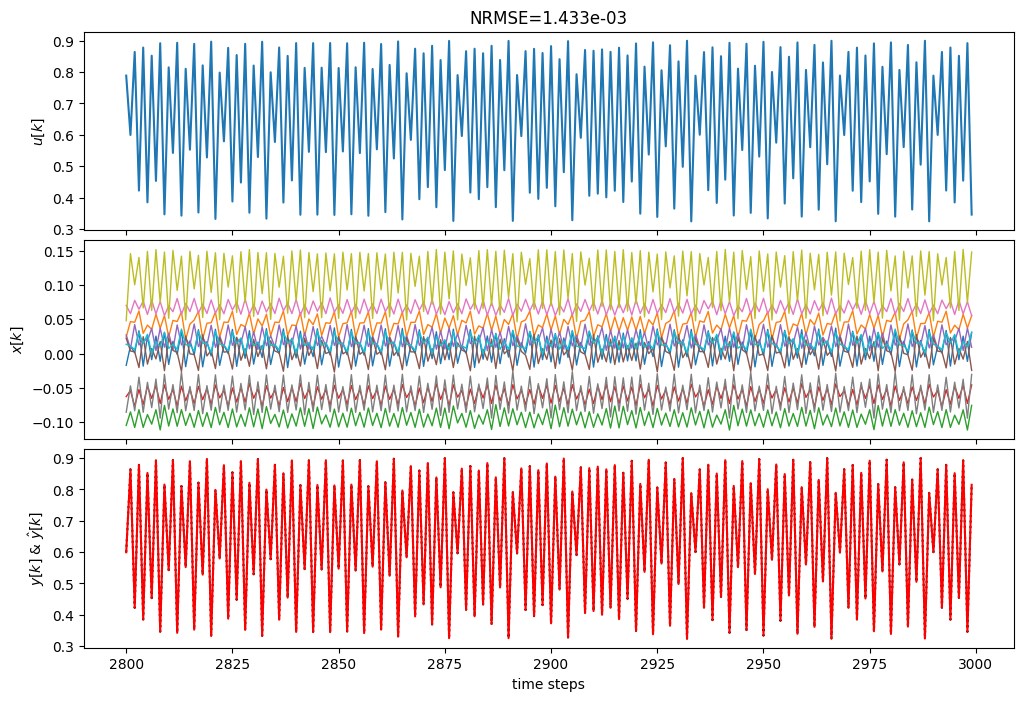

In [ ]:
rnd = np.random.default_rng(1234)
dim_esn, rho, sigma = 100, 0.9, 0.1
t_washout, t_train, t_eval = 100, 2000, 1000
t_total = t_washout + t_train + t_eval

ts = np.arange(-t_washout, t_train + t_eval)
ser = np.array(generate_logistic_series(0.1,3.6,t_total+1)).reshape(-1, 1)
x_init = rnd.uniform(-1, 1, (dim_esn,))
w_in = Linear(1, dim_esn, bound=sigma, bias=0.0, rnd=rnd)
net = ESN(dim_esn, sr=rho, f=np.tanh, init_state=x_init, rnd=rnd)
w_out = LRReadout(dim_esn, 1)

ys = ser[1:]          # shape (t_total, 1)
us = ser[:-1]         # shape (t_total, 1)

x = x_init
xs = np.zeros((t_total, dim_esn))
for idx in range(t_total):
    x = net(x, w_in(us[idx]))
    xs[idx] = x

x_train, y_train = xs[t_washout:-t_eval], ys[t_washout:-t_eval]
x_eval, y_eval = xs[-t_eval:], ys[-t_eval:]
w_out.train(x_train, y_train)
y_out = w_out(x_eval)
nrmse = calc_nrmse(y_eval, y_out)

plot_length = 200

fig, ax = plt.subplots(3, 1, figsize=(12, 8), gridspec_kw={"hspace": 0.05})
ax[0].plot(ts[-plot_length:], us[-plot_length:])
ax[0].set_xticklabels([])
ax[1].plot(ts[-plot_length:], xs[-plot_length:, :10], lw=1.0)
ax[1].set_xticklabels([])
ax[2].plot(ts[-plot_length:], y_eval[-plot_length:], color="k", ls=":", lw=1.5)
ax[2].plot(ts[-plot_length:], y_out[-plot_length:], lw=1.5, color="red")
ax[0].set_title("NRMSE={:.3e}".format(nrmse[0]))
ax[0].set_ylabel(r"$u[k]$")
ax[1].set_ylabel(r"$x[k]$")
ax[2].set_ylabel(r"$y[k]$ & $\hat{y}[k]$")
ax[2].set_xlabel("time steps")

None

Lets do a grid search to find the best hyperparameters, if trying out different values of a, change it here and run all cells below this.

In [ ]:
sigmas = np.linspace(0.0, 1.0, 21)  # [0.05, 0.10, ...., 1.00]
rhos = np.array([0.6, 0.7, 0.8, 0.9])
a = 4.0    #this is the parameter a from the logistic map, change it to any valid quantity for experimentation

nrmse_grid = np.zeros((len(sigmas), len(rhos)))

for i, sigma in enumerate(sigmas):
        for j, rho in enumerate(rhos):
            ser = np.array(generate_logistic_series(0.1,a,t_total+1)).reshape(-1, 1)
            x_init = rnd.uniform(-1, 1, (dim_esn,))
            w_in = Linear(1, dim_esn, bound=sigma, bias=0.0, rnd=rnd)
            net = ESN(dim_esn, sr=rho, f=np.tanh, init_state=x_init, rnd=rnd)
            w_out = LRReadout(dim_esn, 1)

            ys = ser[1:]          # shape (t_total, 1)
            us = ser[:-1]         # shape (t_total, 1)

            x = x_init
            xs = np.zeros((t_total, dim_esn))
            for idx in range(t_total):
                x = net(x, w_in(us[idx]))
                xs[idx] = x

            x_train, y_train = xs[t_washout:-t_eval], ys[t_washout:-t_eval]
            x_eval, y_eval = xs[-t_eval:], ys[-t_eval:]
            w_out.train(x_train, y_train)
            y_out = w_out(x_eval)

            # evaluate
            nrmse_grid[i, j] = calc_nrmse(y_eval, y_out).item()

# find best parameters
best_idx = np.unravel_index(np.argmin(nrmse_grid), nrmse_grid.shape)
best_sigma, best_rho = sigmas[best_idx[0]], rhos[best_idx[1]]
print(f"Best NRMSE={nrmse_grid[best_idx]:.3e}, σ={best_sigma}, ρ={best_rho}")

print("Min NRMSE:", np.min(nrmse_grid))
print("Max NRMSE:", np.max(nrmse_grid))



Best NRMSE=3.012e-02, σ=1.0, ρ=0.6
Min NRMSE: 0.030116824728507827
Max NRMSE: 1.0024140512898108


Now using those best values, we run it again to create the trained ESN and get some nice graphs.

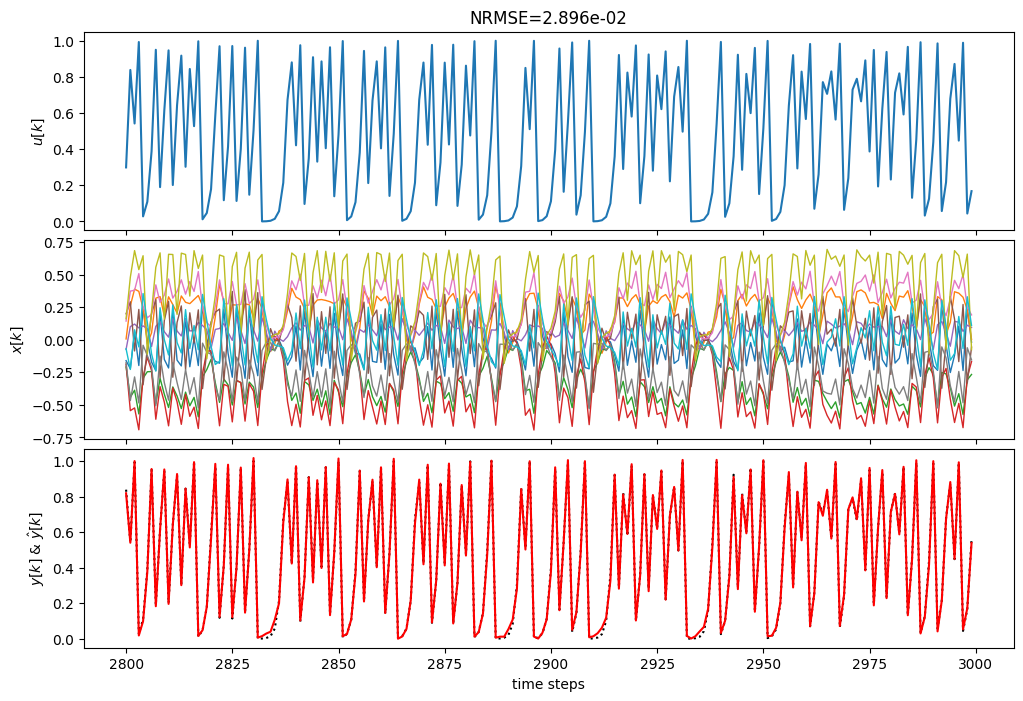

In [ ]:
rnd = np.random.default_rng(1234)
dim_esn, rho, sigma = 100, best_rho, best_sigma
t_washout, t_train, t_eval = 100, 2000, 1000
t_total = t_washout + t_train + t_eval

ts = np.arange(-t_washout, t_train + t_eval)
ser = np.array(generate_logistic_series(0.1,a,t_total+1)).reshape(-1, 1)
x_init = rnd.uniform(-1, 1, (dim_esn,))
w_in = Linear(1, dim_esn, bound=sigma, bias=0.0, rnd=rnd)
net = ESN(dim_esn, sr=rho, f=np.tanh, init_state=x_init, rnd=rnd)
w_out = LRReadout(dim_esn, 1)

ys = ser[1:]          # shape (t_total, 1)
us = ser[:-1]         # shape (t_total, 1)

x = x_init
xs = np.zeros((t_total, dim_esn))
for idx in range(t_total):
    x = net(x, w_in(us[idx]))
    xs[idx] = x

x_train, y_train = xs[t_washout:-t_eval], ys[t_washout:-t_eval]
x_eval, y_eval = xs[-t_eval:], ys[-t_eval:]
w_out.train(x_train, y_train)
y_out = w_out(x_eval)
nrmse = calc_nrmse(y_eval, y_out)

plot_length = 200

fig, ax = plt.subplots(3, 1, figsize=(12, 8), gridspec_kw={"hspace": 0.05})
ax[0].plot(ts[-plot_length:], us[-plot_length:])
ax[0].set_xticklabels([])
ax[1].plot(ts[-plot_length:], xs[-plot_length:, :10], lw=1.0)
ax[1].set_xticklabels([])
ax[2].plot(ts[-plot_length:], y_eval[-plot_length:], color="k", ls=":", lw=1.5)
ax[2].plot(ts[-plot_length:], y_out[-plot_length:], lw=1.5, color="red")
ax[0].set_title("NRMSE={:.3e}".format(nrmse[0]))
ax[0].set_ylabel(r"$u[k]$")
ax[1].set_ylabel(r"$x[k]$")
ax[2].set_ylabel(r"$y[k]$ & $\hat{y}[k]$")
ax[2].set_xlabel("time steps")

None

Now we feed the ESN's prediction for the next step back into the ESN as the next input to predict further into the future.

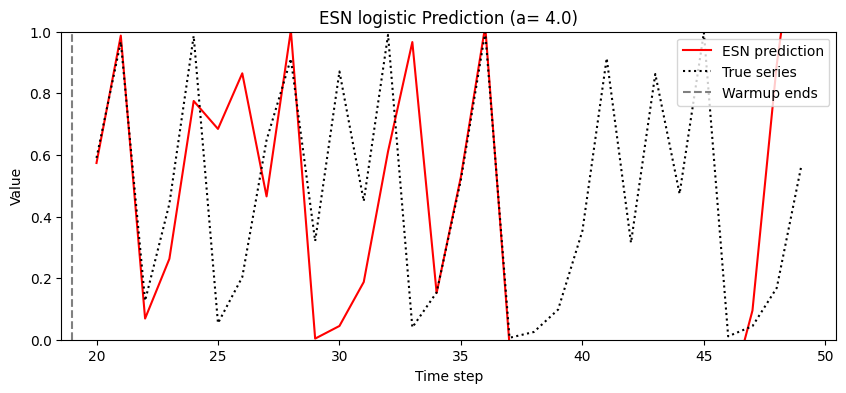

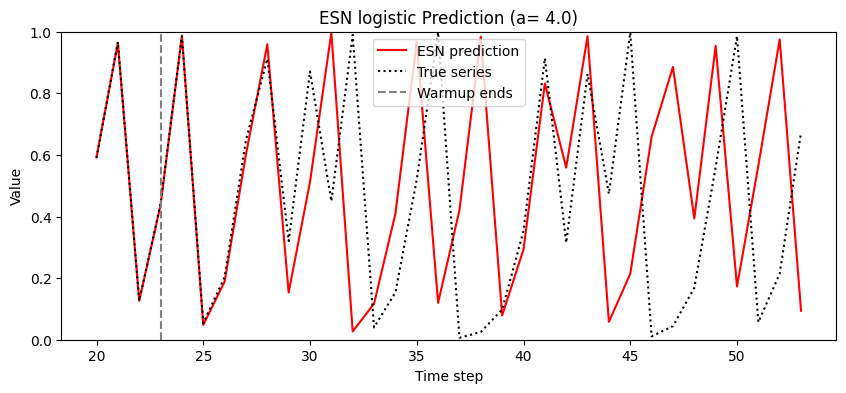

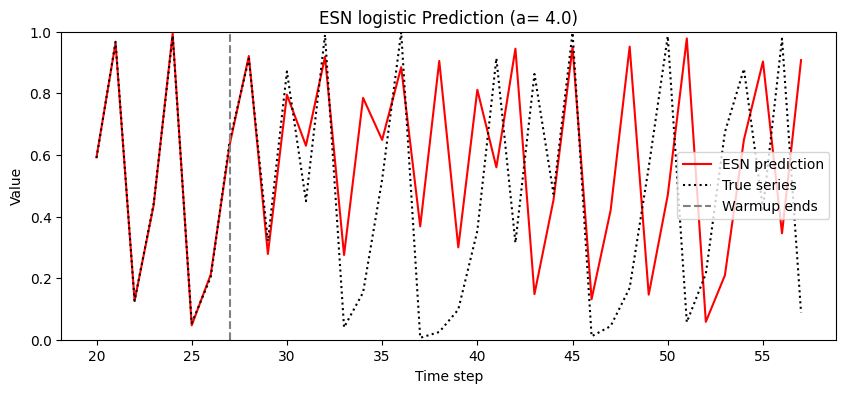

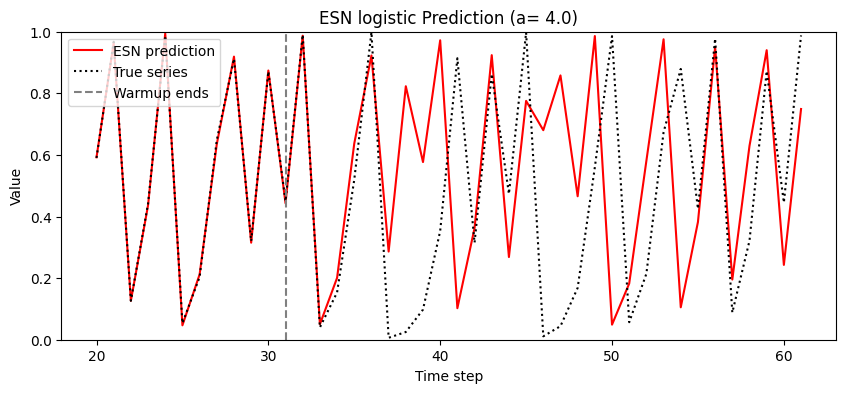

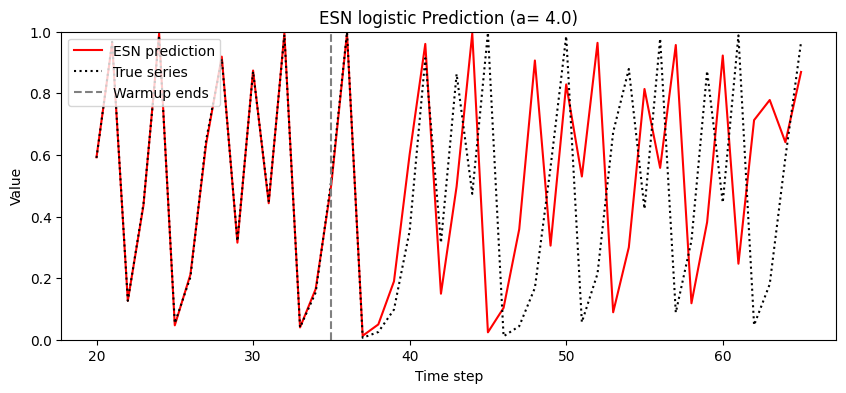

In [ ]:
for w_ind in range(5):
  # --- Parameters ---
  warmup_steps = 20+4*w_ind       #simulate random initial conditions by starting at different indices
  pred_steps = 30
  t_total = warmup_steps + pred_steps

  # --- Prepare storage ---
  x = x_init.copy()                # initial reservoir state
  y_gen = np.zeros((t_total, 1))   # generated output
  u = us[0].copy()                 # starting input (first real data point)

  # --- Warmup: feed real inputs to settle reservoir ---
  for idx in range(warmup_steps):
      x = net(x, w_in(us[idx]))    # update reservoir
      y_pred = w_out(x)            # compute output (optional)
      y_gen[idx] = y_pred          # store predicted output for warmup

  # --- Closed-loop prediction ---
  for idx in range(warmup_steps, t_total):
      u = y_pred                   # feed prediction as next input
      x = net(x, w_in(u))          # update reservoir with last output
      y_pred = w_out(x)            # predict next step
      y_gen[idx] = y_pred          # store prediction

  # --- Plot results starting after 20 steps ---
  plot_start = 20
  plt.figure(figsize=(10,4))
  time_steps = np.arange(plot_start, t_total)

  plt.plot(time_steps, y_gen[plot_start:], 'r', label='ESN prediction')
  plt.plot(time_steps, ys[plot_start:t_total], 'k:', label='True series')

  plt.axvline(warmup_steps - 1, color='gray', linestyle='--', label='Warmup ends')

  plt.xlabel('Time step')
  plt.ylabel('Value')
  plt.title('ESN logistic Prediction (a= '+ str(a) + ')')

  plt.ylim(0, 1)  # <-- set y-axis range

  plt.legend()
  plt.show()